          x           y
0  3.834874  420.200907
1  3.899983  417.981901
2  3.966257  415.801855
3  4.033716  413.659699
4  4.102381  411.554383


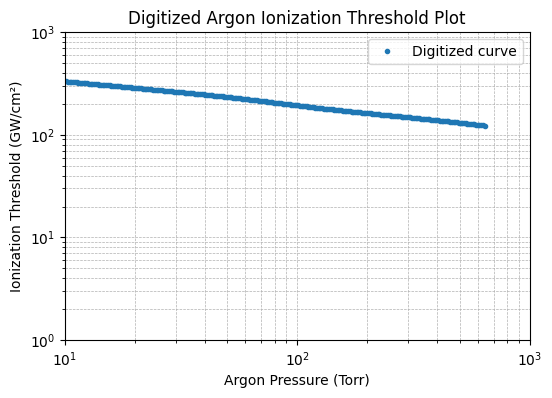

In [2]:
# Step 1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt

# Step 2: Load your CSV
# Replace with your actual CSV file path
csv_file = "Ar_ionization_loglog_digitized.csv"
df = pd.read_csv(csv_file)

# Step 3: Quick check of data
print(df.head())

# Step 4: Create a log–log plot
plt.figure(figsize=(6, 4))

x_torr = df['x']
I_GW = df['y']
plt.loglog(x_torr, I_GW, '.', label="Digitized curve")

# Step 5: Add labels & style
plt.xlabel("Argon Pressure (Torr)")
plt.ylabel("Ionization Threshold (GW/cm²)")
plt.title("Digitized Argon Ionization Threshold Plot")
plt.grid(True, which="both", ls="--", lw=0.5)
plt.xlim(10,1000)
plt.ylim(1,1000)
plt.legend()


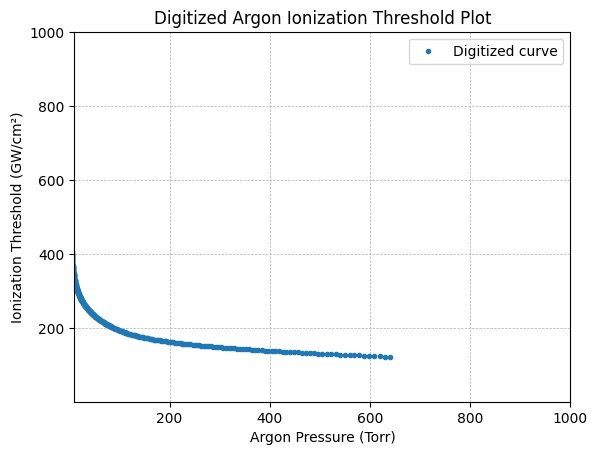

In [3]:
plt.plot(x_torr, I_GW, '.', label="Digitized curve")

# Step 5: Add labels & style
plt.xlabel("Argon Pressure (Torr)")
plt.ylabel("Ionization Threshold (GW/cm²)")
plt.title("Digitized Argon Ionization Threshold Plot")
plt.grid(True, which="both", ls="--", lw=0.5)
plt.xlim(10,1000)
plt.ylim(1,1000)
plt.legend()

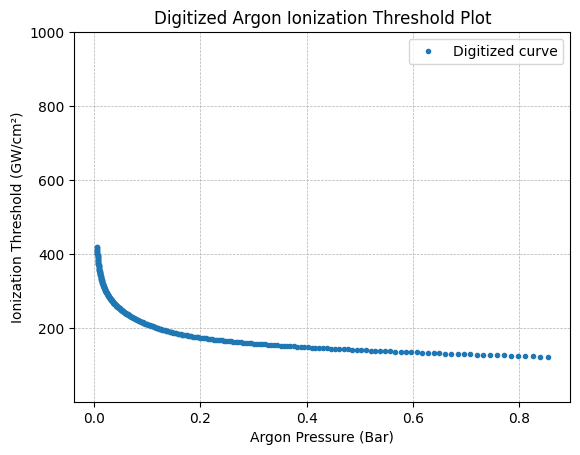

In [4]:
torr_to_bar = 1.33322e-3 #conversion factor from torr to bar
x_bar = x_torr * torr_to_bar

plt.plot(x_bar, I_GW, '.', label="Digitized curve")

# Step 5: Add labels & style
plt.xlabel("Argon Pressure (Bar)")
plt.ylabel("Ionization Threshold (GW/cm²)")
plt.title("Digitized Argon Ionization Threshold Plot")
plt.grid(True, which="both", ls="--", lw=0.5)
#plt.xlim(10,1000)
plt.ylim(1,1000)
plt.legend()

B = -0.2384 ± 0.0010 (95% CI)
I_ref @ P_ref=1 bar = 119.783 GW/cm^2 [119.426, 120.142] (95% CI)
R^2 (log-space) = 0.9987


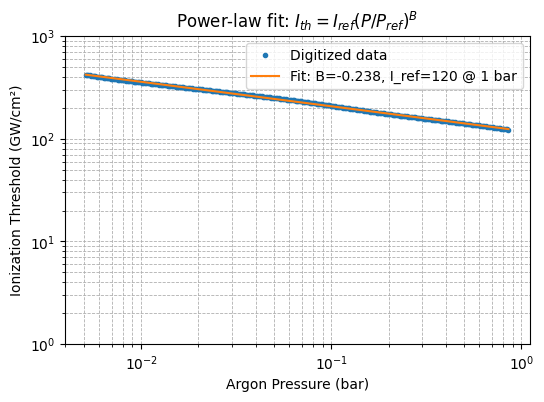

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# --- Input data (you already have these) ---
# x_bar: pressure in bar
# I_GW: ionization threshold in GW/cm^2

# --- Choose your reference pressure ---
P_ref = 1.0  # bar (change if you prefer another reference)

# --- Clean data: keep only finite, positive values ---
mask = np.isfinite(x_bar) & np.isfinite(I_GW) & (x_bar > 0) & (I_GW > 0)
P = np.asarray(x_bar[mask], dtype=float)
I = np.asarray(I_GW[mask], dtype=float)

# --- Fit in log space: log(I) = A + B*log(P) ---
logP = np.log(P)
logI = np.log(I)

# polyfit returns [slope, intercept] for degree=1
[B, A], cov = np.polyfit(logP, logI, 1, cov=True)
se_B = np.sqrt(cov[0, 0])
se_A = np.sqrt(cov[1, 1])

# Convert to your parameterization with P_ref
# I_ref = exp(A + B*log(P_ref))
log_Iref = A + B * np.log(P_ref)
I_ref = np.exp(log_Iref)

# Uncertainty on I_ref via error propagation in log space
# var(log I_ref) = var(A) + (log P_ref)^2 var(B) + 2*(log P_ref)*cov_AB
var_log_Iref = cov[1,1] + (np.log(P_ref)**2) * cov[0,0] + 2*np.log(P_ref)*cov[0,1]
se_log_Iref = np.sqrt(var_log_Iref)
# 95% CI (approx. normal in log space)
I_ref_lo = np.exp(log_Iref - 1.96*se_log_Iref)
I_ref_hi = np.exp(log_Iref + 1.96*se_log_Iref)

# Goodness of fit (R^2 in log space)
logI_pred = A + B*logP
ss_res = np.sum((logI - logI_pred)**2)
ss_tot = np.sum((logI - np.mean(logI))**2)
R2 = 1 - ss_res/ss_tot

print(f"B = {B:.4f} ± {1.96*se_B:.4f} (95% CI)")
print(f"I_ref @ P_ref={P_ref:g} bar = {I_ref:.6g} GW/cm^2 "
      f"[{I_ref_lo:.6g}, {I_ref_hi:.6g}] (95% CI)")
print(f"R^2 (log-space) = {R2:.4f}")

# --- Helper: model function ---
def I_th(P):
    return I_ref * (P / P_ref)**B

# --- Plot ---
fig, ax = plt.subplots(figsize=(6,4))
ax.loglog(P, I, '.', label="Digitized data")

P_fit = np.logspace(np.log10(P.min()), np.log10(P.max()), 400)
ax.loglog(P_fit, I_th(P_fit),
          '-', label=f"Fit: B={B:.3f}, I_ref={I_ref:.3g} @ {P_ref:g} bar")

ax.set_xlabel("Argon Pressure (bar)")
ax.set_ylabel("Ionization Threshold (GW/cm²)")
ax.set_title("Power-law fit: $I_{th}=I_{ref}(P/P_{ref})^B$")
ax.grid(True, which="both", ls="--", lw=0.6)
ax.legend()
plt.ylim(1, 1000)  # keep your y-limits if you like
plt.show()


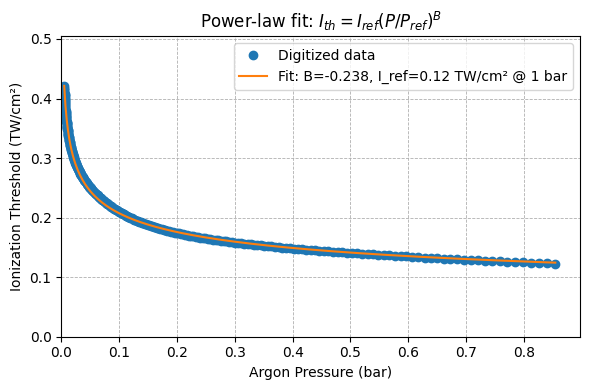

In [41]:
# --- Plot in TW/cm², linear axes ---
fig, ax = plt.subplots(figsize=(6,4))

# Convert data and fit to TW/cm²
I_TW = I / 1000
def I_th_TW(P): return I_th(P) / 1000

ax.plot(P, I_TW, 'o', label="Digitized data")

P_fit = np.linspace(P.min(), P.max(), 400)
ax.plot(P_fit, I_th_TW(P_fit),
        '-', label=f"Fit: B={B:.3f}, I_ref={I_ref/1000:.3g} TW/cm² @ {P_ref:g} bar")

ax.set_xlabel("Argon Pressure (bar)")
ax.set_ylabel("Ionization Threshold (TW/cm²)")
ax.set_title("Power-law fit: $I_{th}=I_{ref}(P/P_{ref})^B$")
ax.grid(True, ls="--", lw=0.6)
ax.legend()
plt.ylim(0, (I_TW.max()*1.2))  # nice margin above data
plt.xlim(0, P.max()*1.05)      # linear x-axis
plt.tight_layout()
plt.show()


# Kaumanns 18mJ paper:

24.1954447094433


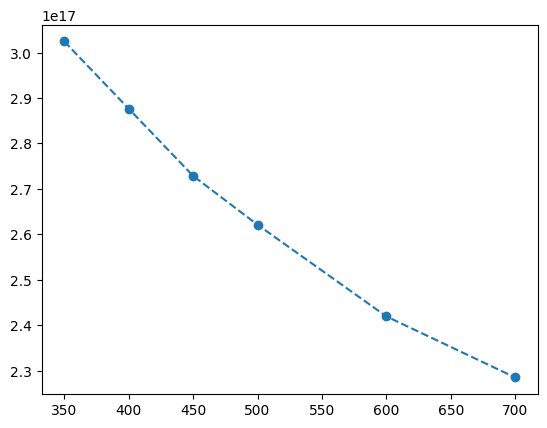

In [32]:
w0 = 0.37e-3/2 #spot size (1/e^2 radius) in the focus
E = 18e-3
tau_FWHM = 1.3e-12 #pulse length in Kaumann's paper
tau = tau_FWHM/(2*np.sqrt(2*np.log(2)))
I0 = np.sqrt(2/np.pi**3)*E/(w0**2*tau)

print(I0/1e16)

E_break = np.array([22.5,21.4,20.3,19.5,18,17])*1e-3
I_break = np.sqrt(2/np.pi**3)*E_break/(w0**2*tau)
mbar_break = [350,400,450,500,600,700]

plt.plot(mbar_break,I_break,'--o')
#plt.ylim(16,24)


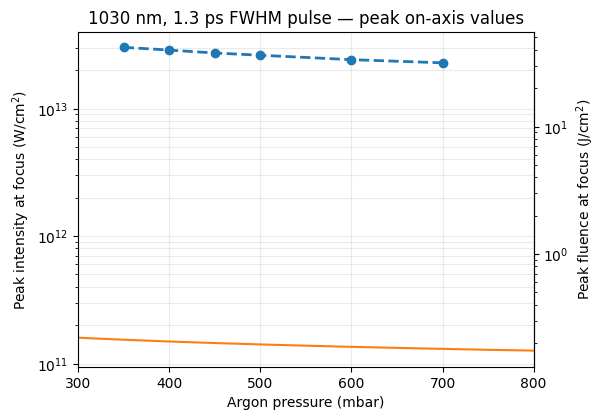

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# Given parameters
w0 = 0.37e-3/2  # m
E = 18e-3     # J
tau_FWHM = 1.3e-12  # s
tau = tau_FWHM/(2*np.sqrt(2*np.log(2)))

I0 = np.sqrt(2/np.pi**3) * E / (w0**2 * tau)

E_break = np.array([22.5, 21.4, 20.3, 19.5, 18.0, 17.0]) * 1e-3  # J
I_break = np.sqrt(2/np.pi**3) * E_break / (w0**2 * tau)          # W/m^2
mbar_break = np.array([350, 400, 450, 500, 600, 700])

# --- Unit conversions ---
def Wm2_to_Wcm2(I): return I / 1e4
def Wcm2_to_Wm2(I): return I * 1e4
def Icm2_to_Fcm2(Icm): return Icm * tau * np.sqrt(2*np.pi)
def Fcm2_to_Icm2(Fcm): return Fcm / (tau * np.sqrt(2*np.pi))

I_break_cm = Wm2_to_Wcm2(I_break)

# --- Plot ---
fig, ax = plt.subplots(figsize=(6,4.5))
ax.plot(mbar_break, I_break_cm, '--o', lw=2, ms=6)

ax.set_xlabel('Argon pressure (mbar)')
ax.set_ylabel('Peak intensity at focus (W/cm$^2$)')

# Secondary axis (fluence)
secax = ax.secondary_yaxis('right', functions=(Icm2_to_Fcm2, Fcm2_to_Icm2))
secax.set_ylabel('Peak fluence at focus (J/cm$^2$)')

# --- Format intensity axis only ---
fmt_intensity = ScalarFormatter(useMathText=True)
fmt_intensity.set_powerlimits((0, 0))   # always scientific notation
ax.yaxis.set_major_formatter(fmt_intensity)
ax.ticklabel_format(axis="y", style="sci", scilimits=(0,0))
ax.yaxis.get_offset_text().set_fontsize(10)

# Fluence axis left as default
# secax.yaxis.set_major_formatter(...)  <-- don't touch this one

# Niceties
ax.grid(True, which='both', alpha=0.25)
ax.set_title('1030 nm, 1.3 ps FWHM pulse — peak on-axis values')

plt.tight_layout()
plt.xlim(300,800)

ax.plot(P_fit*1000, I_th_TW(P_fit)*1e12,
        '-', label=f"Fit: B={B:.3f}, I_ref={I_ref/1000:.3g} TW/cm² @ {P_ref:g} bar")
ax.set_yscale('log')


# Other resources on Argon ionization:

Fitted power law: I(p) = 3.337e+14 * p^-0.410


/var/folders/0_/nrrxny_x54j3w76q939n8pth0000gn/T/ipykernel_88433/128132981.py:37: RuntimeWarning: divide by zero encountered in power
  I_power = A * p_grid**n


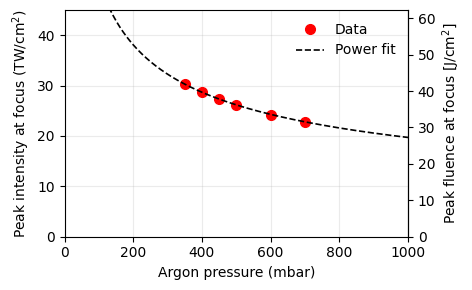

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# --- Your parameters ---
w0 = 0.37e-3/2  # m
E = 18e-3       # J
tau_FWHM = 1.3e-12  # s
tau = tau_FWHM/(2*np.sqrt(2*np.log(2)))

I0 = np.sqrt(2/np.pi**3) * E / (w0**2 * tau)

E_break = np.array([22.5, 21.4, 20.3, 19.5, 18.0, 17.0]) * 1e-3  # J
I_break = np.sqrt(2/np.pi**3) * E_break / (w0**2 * tau)          # W/m^2
mbar_break = np.array([350, 400, 450, 500, 600, 700])

# --- Unit conversions ---
def Wm2_to_Wcm2(I): return I / 1e4
def Wcm2_to_Wm2(I): return I * 1e4
def Icm2_to_Fcm2(Icm): return Icm * tau * np.sqrt(2*np.pi)
def Fcm2_to_Icm2(Fcm): return Fcm / (tau * np.sqrt(2*np.pi))

I_break_cm = Wm2_to_Wcm2(I_break)

# --- Power-law fit: I = A * p^n ---
logp = np.log(mbar_break)
logI = np.log(I_break_cm)

coef = np.polyfit(logp, logI, deg=1)   # linear fit in log–log
n = coef[0]
A = np.exp(coef[1])

print(f"Fitted power law: I(p) = {A:.3e} * p^{n:.3f}")

# Interpolated pressures
p_grid = np.linspace(0, 1000, 400)
I_power = A * p_grid**n

# Specific query points
p_queries = np.array([160, 1000])
I_queries = A * p_queries**n
F_queries = Icm2_to_Fcm2(I_queries)

# --- Plot ---
fig, ax = plt.subplots(figsize=(5,3))

# Convert intensities to TW/cm^2 (divide by 1e12)
ax.plot(mbar_break, I_break_cm/1e12, 'o', ms=7, label='Data', color='red')
ax.plot(p_grid, I_power/1e12, lw=1.2, label=f'Power fit', color='black', ls='dashed')
#ax.plot(p_queries, I_queries/1e12, 's', ms=7, label='Interpolated')

ax.set_xlabel('Argon pressure (mbar)')
ax.set_ylabel('Peak intensity at focus (TW/cm$^2$)')

# Secondary axis (fluence) stays as J/cm²
secax = ax.secondary_yaxis('right',
                           functions=(lambda I_TW: Icm2_to_Fcm2(I_TW*1e12),
                                      lambda F: Fcm2_to_Icm2(F)/1e12))
secax.set_ylabel('Peak fluence at focus [J/cm$^2$]')

ax.grid(True, which='both', alpha=0.25)
#ax.set_title('Breakdown threshold vs Argon pressure\n(1030 nm, 1.3 ps FWHM)')
ax.set_xlim(0, 1000)
ax.legend(frameon=False, loc='best')

plt.tight_layout()
ax.set_ylim(0, 45)  # TW/cm^2 range instead of 4e13 W/cm^2
plt.show()

